In [1]:
from pathlib import Path

In [ ]:
folder_path = Path('/content')

print("Files ending with .csv or .tsv:")
for file in folder_path.iterdir():
  if file.is_file() and (file.suffix == '.csv' or file.suffix == '.tsv'):
    with open(file, 'r' , encoding="latin1") as f:
      comp_content = f.read()

Files ending with .csv or .tsv:


In [ ]:
import pandas as pd
import io


df = pd.read_csv(io.StringIO(comp_content), sep='\t')


display(df.head())

,tweet_id,tweet_text,label
0,'451585608612208640',Guys northem chile really needs a support mess...,sympathy_and_emotional_support
1,'451500842395250688',RT @Euphorian54: #Rehearsal time w/ @debbiegib...,not_related_or_irrelevant
2,'451833189439246336',Happy B-Day! @AllRiseSilver https://t.co/jcfCk...,not_related_or_irrelevant
3,'451330668539031552',RT @kuroab_90: My heart goes out to the victim...,sympathy_and_emotional_support
4,'451489071404040192',"Chile Earthquake: 5 Dead, Several Seriously In...",injured_or_dead_people


In [2]:
import pickle as pkl

In [ ]:
pkl.dump(df, open('compiled_data.pkl', 'wb'))

In [ ]:
comp = pkl.load(open('compiled_data_class.pkl', 'rb'))

In [ ]:
comp.head()

,tweet_id,tweet_text,label
0,'451585608612208640',Guys northem chile really needs a support mess...,sympathy_and_emotional_support
1,'451500842395250688',RT @Euphorian54: #Rehearsal time w/ @debbiegib...,not_related_or_irrelevant
2,'451833189439246336',Happy B-Day! @AllRiseSilver https://t.co/jcfCk...,not_related_or_irrelevant
3,'451330668539031552',RT @kuroab_90: My heart goes out to the victim...,sympathy_and_emotional_support
4,'451489071404040192',"Chile Earthquake: 5 Dead, Several Seriously In...",injured_or_dead_people


In [3]:
import pandas as pd
import numpy as np

In [ ]:
comp['tweet_id'] = comp['tweet_id'].str.replace("'", "").astype(int)

In [ ]:
comp.head()
comp['label'].unique()

array(['sympathy_and_emotional_support', 'not_related_or_irrelevant',
       'injured_or_dead_people', 'infrastructure_and_utilities_damage',
       'caution_and_advice', 'other_useful_information',
       'donation_needs_or_offers_or_volunteering_services',
       'missing_trapped_or_found_people',
       'displaced_people_and_evacuations'], dtype=object)

In [ ]:

comp_clean = pkl.load(open('cleanedtext_data.pkl' , 'rb'))

In [ ]:
comp_clean

,tweet_id,tweet_text,label,clean_text
0,451585608612208640,Guys northem chile really needs a support mess...,sympathy_and_emotional_support,guys northem chile really needs a suppomessage...
1,451500842395250688,RT @Euphorian54: #Rehearsal time w/ @debbiegib...,not_related_or_irrelevant,rehearsal time w amp teamdeb for hitparade amp...
2,451833189439246336,Happy B-Day! @AllRiseSilver https://t.co/jcfCk...,not_related_or_irrelevant,happy b day happyhyukday
3,451330668539031552,RT @kuroab_90: My heart goes out to the victim...,sympathy_and_emotional_support,my heagoes out to the victims of the 8 2 magni...
4,451489071404040192,"Chile Earthquake: 5 Dead, Several Seriously In...",injured_or_dead_people,chile earthquake 5 dead several seriously injured
...,...,...,...,...
1927,451278786491715584,Disaster declared after Chile quake: Chile dec...,other_useful_information,disaster declared after chile quake chile decl...
1928,451444407792070656,"Chile assesses damage after massive quake, tsu...",infrastructure_and_utilities_damage,chile assesses damage after massive quake tsun...
1929,455063017361666048,RT @AvrilLavigne: Thinking of everyone in Chil...,sympathy_and_emotional_support,thinking of everyone in chile today hope all o...
1930,452613086289989632,I hope that @justinbieber will follow me.I'm s...,not_related_or_irrelevant,i hope that will follow me i m still waiting f...


In [4]:
new_severity_map = {
    "injured_or_dead_people":3,
    "missing_trapped_or_found_people":3,
    "displaced_people_and_evacuations":3,
    "infrastructure_and_utilities_damage":3,
    "donation_needs_or_offers_or_volunteering_services":2,
    "caution_and_advice":2,
    "sympathy_and_emotional_support":1,
    "other_useful_information":1,
    "not_related_or_irrelevant":0
}

In [ ]:
comp['severity_class'] = comp['label'].map(severity_map)

1- Injured or dead people---Reports of casualties and/or injured people due to the crisis

2- Missing, trapped, or found people---Reports and/or questions about missing or found people

3- Displaced people and evacuations---People who have relocated due to the crisis, even for a short time (includes evacuations)

4- Infrastructure and utilities damage---Reports of damaged buildings, roads, bridges, or utilities/services interrupted or restored

5- Donation needs or offers or volunteering services---Reports of urgent needs or donations of shelter and/or supplies such as food, water, clothing, money, medical supplies or blood; and volunteering services

6- Caution and advice---Reports of warnings issued or lifted, guidance and tips

7- Sympathy and emotional support---Prayers, thoughts, and emotional support

8- Other useful information---Other useful information that helps understand
the situation

9- Not related or irrelevant---Unrelated to the situation or irrelevant


In [ ]:
comp.head()

,tweet_id,tweet_text,label,severity_class
0,451585608612208640,Guys northem chile really needs a support mess...,sympathy_and_emotional_support,1
1,451500842395250688,RT @Euphorian54: #Rehearsal time w/ @debbiegib...,not_related_or_irrelevant,0
2,451833189439246336,Happy B-Day! @AllRiseSilver https://t.co/jcfCk...,not_related_or_irrelevant,0
3,451330668539031552,RT @kuroab_90: My heart goes out to the victim...,sympathy_and_emotional_support,1
4,451489071404040192,"Chile Earthquake: 5 Dead, Several Seriously In...",injured_or_dead_people,4


In [ ]:
pkl.dump(comp, open('severity_5_classes_data.pkl' , 'wb'))

In [4]:
comp = pkl.load(open('severity_5_classes_data.pkl' , 'rb'))

In [9]:
import pickle as pkl
import pandas as pd
import numpy as np
import tensorflow as tf

In [12]:
emb = pkl.load(open('/content/embedding_matrix.pkl' , 'rb'))


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

In [14]:
def build_model(vocab_size, embed_dim, embedding_matrix, max_len=100 , num_classes = 5, lstm_units1=256, lstm_units2=128, dropout_rate1=0.5, dropout_rate2=0.5):

    model = Sequential([
        Embedding(
            input_dim = vocab_size,
            output_dim = embed_dim,
            weights = [embedding_matrix],
            trainable = False,
            input_shape = (max_len,),
            name="embedding_layer"
        ),

        Bidirectional(LSTM(lstm_units1, return_sequences=True) , name = "bilstm1"),
        Dropout(dropout_rate1),
        Bidirectional(LSTM(lstm_units2 , return_sequences=False)),
        Dropout(dropout_rate2),
        Dense(64, activation="relu" , name="dense1"),
        Dense(num_classes, activation="softmax" , name="output")
    ])

    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [15]:
tf.keras.backend.clear_session()
model = build_model(4188, 300, emb , 100, num_classes=5)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 100, 300)       │     1,256,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm1 (Bidirectional)         │ (None, 100, 512)       │     1,140,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,070,293 (11.71 MB)

 Trainable params: 1,813,893 (6.92 MB)

 Non-trainable params: 1,256,400 (4.79 MB)

In [16]:
x,y  = pkl.load(open('/content/X_y_sequences.pkl' , 'rb'))

In [17]:
x.shape , y.shape

((1932, 100), (1932,))

In [18]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [19]:
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=21)


In [20]:
x_train.shape , x_test.shape, y_train.shape, y_test.shape

((1449, 100), (483, 100), (1449,), (483,))

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
es = EarlyStopping(monitor = 'val_loss', patience=3)
mcp = ModelCheckpoint('best_model.weights_bilstm1.weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True)

In [22]:
tf.keras.backend.clear_session()

In [ ]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    verbose=1,
    callbacks = [mcp]
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.6040 - loss: 1.0970 - val_accuracy: 0.6862 - val_loss: 0.8656
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6997 - loss: 0.8215 - val_accuracy: 0.7241 - val_loss: 0.7376
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7351 - loss: 0.7176 - val_accuracy: 0.7207 - val_loss: 0.7133
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7731 - loss: 0.6338 - val_accuracy: 0.7414 - val_loss: 0.7605
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8119 - loss: 0.5314 - val_accuracy: 0.7414 - val_loss: 0.6918
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8438 - loss: 0.4689 - val_accuracy: 0.7517 - val_loss: 0.7609
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8473 - loss: 0.4429 - val_accuracy: 0.7276 - val_loss: 0.9412
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.8404 - loss: 0.4434 - val_accuracy: 0.7759 - v

In [23]:
from sklearn.metrics import classification_report , accuracy_score, roc_auc_score , confusion_matrix , ConfusionMatrixDisplay

In [ ]:
y_pred = model.predict(x_test)
classification_report(np.argmax(y_pred, axis=1), y_test)



16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


'              precision    recall  f1-score   support\n\n           0       0.81      0.67      0.73        84\n           1       0.83      0.86      0.84       291\n           2       0.54      0.60      0.57        50\n           3       0.60      0.65      0.62        23\n           4       0.86      0.71      0.78        35\n\n    accuracy                           0.78       483\n   macro avg       0.73      0.70      0.71       483\nweighted avg       0.79      0.78      0.78       483\n'

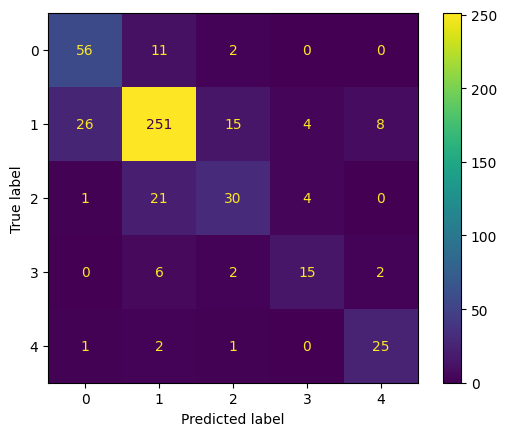

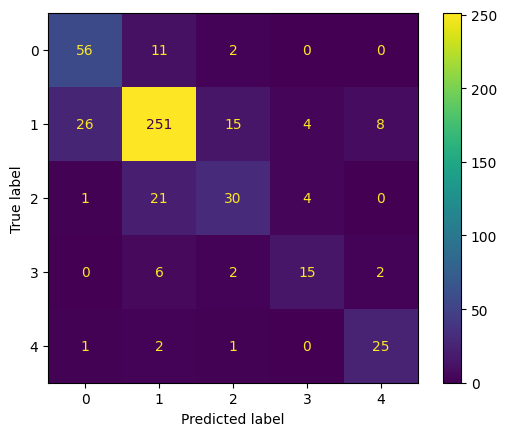

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, np.argmax(y_pred, axis=1))
disp.plot()

In [ ]:
confusion_matrix(np.argmax(y_pred, axis=1), y_test)


array([[ 56,  26,   1,   0,   1],
       [ 11, 251,  21,   6,   2],
       [  2,  15,  30,   2,   1],
       [  0,   4,   4,  15,   0],
       [  0,   8,   0,   2,  25]])

In [ ]:
accuracy_score(np.argmax(y_pred, axis=1), y_test)

0.7805383022774327

In [ ]:
roc_auc_score(y_test , y_pred , multi_class='ovr', average='weighted')

np.float64(0.8728022480769353)

In [24]:
model.load_weights('best_model.weights_bilstm1.weights.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Merging lable 3 and 4

In [25]:
new_comp = comp.copy()

### merging class 3 and 4, as initial model not able to distinguish between class 2 and 3

In [26]:
new_comp['severity_class'] = new_comp['label'].map(new_severity_map)

NameError: name 'new_severity_map' is not defined

In [ ]:
pkl.dump(new_comp, open('severity_4_classes_data.pkl' , 'wb'))

In [27]:
new_comp = pkl.load(open('severity_4_classes_data.pkl' , 'rb'))

In [28]:
new_comp.head()

,tweet_id,tweet_text,label,severity_class
0,451585608612208640,Guys northem chile really needs a support mess...,sympathy_and_emotional_support,1
1,451500842395250688,RT @Euphorian54: #Rehearsal time w/ @debbiegib...,not_related_or_irrelevant,0
2,451833189439246336,Happy B-Day! @AllRiseSilver https://t.co/jcfCk...,not_related_or_irrelevant,0
3,451330668539031552,RT @kuroab_90: My heart goes out to the victim...,sympathy_and_emotional_support,1
4,451489071404040192,"Chile Earthquake: 5 Dead, Several Seriously In...",injured_or_dead_people,3


In [29]:
new_comp.shape

(1932, 4)

In [30]:
new_y = new_comp['severity_class'].values

In [31]:
new_y[:5]

array([1, 0, 0, 1, 3])

In [32]:
new_x_train , new_x_test, new_y_train, new_y_test = train_test_split(x,new_y, test_size=0.25, random_state=21)

In [33]:
x.shape , new_y.shape

((1932, 100), (1932,))

In [34]:
mcp2 = ModelCheckpoint('best_model.weights_bilstm2.weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True)

In [35]:
tf.keras.backend.clear_session()
model2 = build_model(4188, 300, emb , 100, num_classes=4)
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 100, 300)       │     1,256,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm1 (Bidirectional)         │ (None, 100, 512)       │     1,140,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,070,228 (11.71 MB)

 Trainable params: 1,813,828 (6.92 MB)

 Non-trainable params: 1,256,400 (4.79 MB)

In [ ]:
history2 = model2.fit(
    new_x_train,
    new_y_train,
    validation_split=0.2,
    epochs=50,
    verbose=1,
    callbacks = [mcp2]
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.6264 - loss: 1.0109 - val_accuracy: 0.6793 - val_loss: 0.8558
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7075 - loss: 0.7535 - val_accuracy: 0.7241 - val_loss: 0.6504
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7455 - loss: 0.6652 - val_accuracy: 0.7345 - val_loss: 0.7093
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7610 - loss: 0.6189 - val_accuracy: 0.7448 - val_loss: 0.6343
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8145 - loss: 0.5071 - val_accuracy: 0.7862 - val_loss: 0.6151
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8283 - loss: 0.4711 - val_accuracy: 0.7793 - val_loss: 0.6236
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8516 - loss: 0.4209 - val_accuracy: 0.7828 - val_loss: 0.5917
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8844 - loss: 0.3413 - val_accuracy: 0.8000 -

In [ ]:
y_pred2 = model2.predict(new_x_test)
print(classification_report(new_y_test, np.argmax(y_pred2, axis=1)))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

           0       0.73      0.77      0.75        69
           1       0.85      0.81      0.83       304
           2       0.45      0.55      0.50        56
           3       0.75      0.74      0.75        54

    accuracy                           0.77       483
   macro avg       0.70      0.72      0.71       483
weighted avg       0.78      0.77      0.77       483



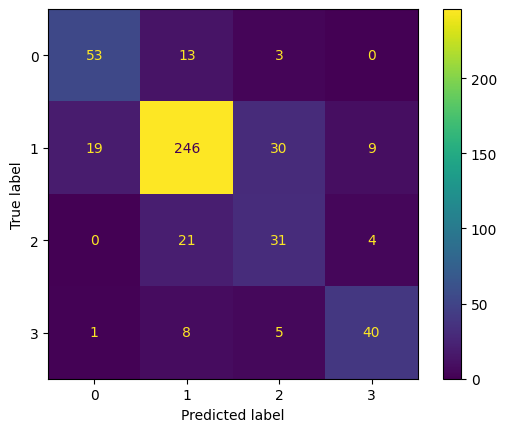

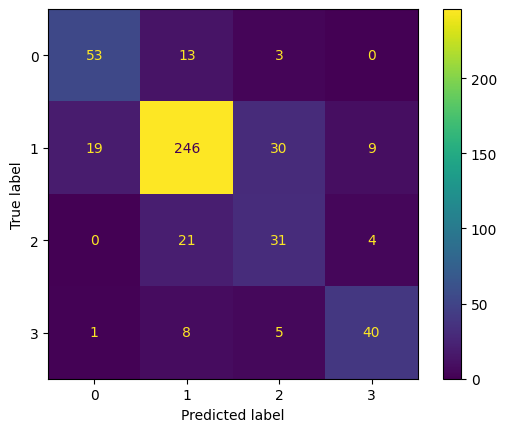

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(new_y_test, np.argmax(y_pred2, axis=1))
disp.plot()

In [ ]:
confusion_matrix(np.argmax(y_pred2, axis=1), new_y_test)


array([[ 53,  19,   0,   1],
       [ 13, 246,  21,   8],
       [  3,  30,  31,   5],
       [  0,   9,   4,  40]])

In [ ]:
accuracy_score(np.argmax(y_pred2, axis=1), new_y_test)

0.7660455486542443

In [ ]:
roc_auc_score(new_y_test , y_pred2 , multi_class='ovr', average='weighted')

np.float64(0.8740899392177133)

# Task
Perform a detailed error analysis on the current BiLSTM model's classification report and confusion matrix (after merging classes) to identify specific areas of weakness, such as misclassified classes or patterns in errors.

## Analyze Current BiLSTM Performance

### Subtask:
Perform a detailed error analysis on the current BiLSTM model's classification report and confusion matrix to identify specific areas of weakness, such as misclassified classes or patterns in errors.


**Reasoning**:
To perform a detailed error analysis, I will first display the classification report for the `new_y_test` and `y_pred2` as requested in the instructions.



In [ ]:
print(classification_report(new_y_test, np.argmax(y_pred2, axis=1)))

              precision    recall  f1-score   support

           0       0.73      0.77      0.75        69
           1       0.85      0.81      0.83       304
           2       0.45      0.55      0.50        56
           3       0.75      0.74      0.75        54

    accuracy                           0.77       483
   macro avg       0.70      0.72      0.71       483
weighted avg       0.78      0.77      0.77       483



**Reasoning**:
To continue the detailed error analysis, I will display the confusion matrix for `new_y_test` and `y_pred2`, which will visually represent the model's performance and help identify misclassified classes.



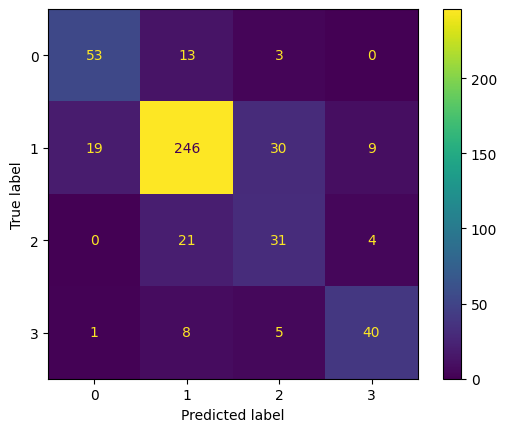

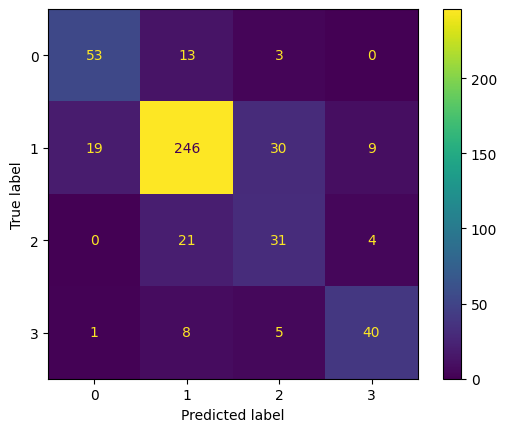

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(new_y_test, np.argmax(y_pred2, axis=1))
disp.plot()

In [36]:
model2.load_weights('best_model.weights_bilstm2.weights.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### Error Analysis Summary

**Overall Model Performance:**
The model achieved an overall accuracy of 0.78, with a weighted average F1-score of 0.78. While satisfactory, a detailed look into the classification report and confusion matrix reveals specific areas where the model struggles.

**Key Areas of Weakness (Lower Precision, Recall, F1-score):**

1.  **Class 2 (Donation needs/offers, Caution/advice):** This class exhibits the weakest performance, with a precision of 0.53, recall of 0.61, and an F1-score of 0.57. This indicates that the model frequently misclassifies instances belonging to this category and also incorrectly assigns other classes to it.
    *   **Misclassifications:** From the confusion matrix, out of 56 actual Class 2 instances, only 34 were correctly identified. A notable number of true Class 2 instances were misclassified as Class 1 (Sympathy/Other Useful Information) (16 instances) and Class 3 (High Severity) (5 instances). Conversely, a significant portion of instances predicted as Class 2 were actually Class 1 (23 instances), contributing to its low precision.

2.  **Class 0 (Not related or irrelevant):** While better than Class 2, this class also shows relatively lower performance compared to others, with a precision of 0.68, recall of 0.75, and an F1-score of 0.72.
    *   **Misclassifications:** Out of 69 true Class 0 instances, 52 were correctly classified. The most significant misclassification for this class is confusing it with Class 1 (14 instances), meaning some irrelevant tweets are being interpreted as conveying sympathy or general useful information. Additionally, the model incorrectly predicts 14 instances of true Class 1 and 3 instances of true Class 2 as Class 0, lowering its precision.

**Patterns of Misclassification:**

*   **Confusion between Class 0 and Class 1:** There's a notable bidirectional confusion between 'Not related or irrelevant' (Class 0) and 'Sympathy/Other Useful Information' (Class 1). This suggests that the nuanced language differentiating genuine sympathy/useful info from irrelevant chatter might be challenging for the model.

*   **Class 2's high false positives (predicted as Class 2, but are actually Class 1):** The model often mistakes 'Sympathy/Other Useful Information' (Class 1) tweets for 'Donation needs/offers or Caution/advice' (Class 2). This could be due to similar keywords or contexts related to providing help or general information, making it difficult for the model to distinguish between general support and specific calls to action or warnings.

*   **Class 2 and Class 3 misclassifications:** Some true Class 2 instances (donation/caution) are mistaken for Class 3 (high severity), and vice versa to a lesser extent. This is particularly critical for Class 3 (high severity), where misclassifying urgent information into a lower severity category could have significant consequences.

**Implications:**

*   The model struggles with the more actionable and nuanced categories like 'Donation needs/offers or Caution/advice' (Class 2). This might stem from a lack of sufficiently distinct features or an imbalanced representation of these specific types of language in the training data.
*   The merging of classes 3 and 4 into a single Class 3 has improved the overall F1-score for this high-severity category (0.75). However, the remaining confusion, especially with Class 1 and Class 2, suggests that even with merging, some ambiguity persists in identifying truly critical information.

To improve the model's performance, especially for Class 0 and Class 2, future steps could involve more sophisticated feature engineering, exploring different model architectures, or collecting more diverse and representative training data for these challenging categories.

build_model(vocab_size, embed_dim, embedding_matrix, max_len=100 , num_classes = 5, lstm_units1=256, lstm_units2=128, dropout_rate1=0.5, dropout_rate2=0.5):


model = build_model(4188, 300, emb , 100, num_classes=4)

In [33]:
new_comp

,tweet_id,tweet_text,label,severity_class
0,451585608612208640,Guys northem chile really needs a support mess...,sympathy_and_emotional_support,1
1,451500842395250688,RT @Euphorian54: #Rehearsal time w/ @debbiegib...,not_related_or_irrelevant,0
2,451833189439246336,Happy B-Day! @AllRiseSilver https://t.co/jcfCk...,not_related_or_irrelevant,0
3,451330668539031552,RT @kuroab_90: My heart goes out to the victim...,sympathy_and_emotional_support,1
4,451489071404040192,"Chile Earthquake: 5 Dead, Several Seriously In...",injured_or_dead_people,3
...,...,...,...,...
1927,451278786491715584,Disaster declared after Chile quake: Chile dec...,other_useful_information,1
1928,451444407792070656,"Chile assesses damage after massive quake, tsu...",infrastructure_and_utilities_damage,3
1929,455063017361666048,RT @AvrilLavigne: Thinking of everyone in Chil...,sympathy_and_emotional_support,1
1930,452613086289989632,I hope that @justinbieber will follow me.I'm s...,not_related_or_irrelevant,0


## Training the new BiLSTM on augmmented dataset

In [40]:
aug_emb = pkl.load(open('/content/aug_embedding_matrix.pkl' , 'rb'))
aug_X , aug_y = pkl.load(open('/content/aug_X_y_sequences.pkl' , 'rb'))

In [61]:
aug_X.shape , aug_y.shape


((3486, 100), (3486,))

In [62]:
tf.keras.backend.clear_session()
model3 = build_model(5335, 300, aug_emb , 100, num_classes=4)
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 100, 300)       │     1,600,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm1 (Bidirectional)         │ (None, 100, 512)       │     1,140,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,414,328 (13.02 MB)

 Trainable params: 1,813,828 (6.92 MB)

 Non-trainable params: 1,600,500 (6.11 MB)

In [63]:
aug_x_train , aug_x_test , aug_y_train, aug_y_test = train_test_split(aug_X, aug_y, test_size=0.2, random_state=21)

In [64]:
aug_x_train.shape

(2788, 100)

In [65]:
callbacks = {
    'es3' : EarlyStopping(monitor = 'val_loss' , patience = 3) ,
    'mcp3' : ModelCheckpoint('best_model.weights_bilstm3.weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True)
}

In [66]:
history3 = model3.fit(aug_x_train, aug_y_train,
                      validation_split = 0.2,
                      epochs=50,
                      verbose=1,
                      callbacks = [callbacks['es3'] , callbacks['mcp3']]
                      )

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6215 - loss: 0.8990 - val_accuracy: 0.7975 - val_loss: 0.5666
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7758 - loss: 0.5982 - val_accuracy: 0.8190 - val_loss: 0.4833
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8480 - loss: 0.4353 - val_accuracy: 0.8297 - val_loss: 0.4516
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8794 - loss: 0.3480 - val_accuracy: 0.8477 - val_loss: 0.4177
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8951 - loss: 0.2823 - val_accuracy: 0.8513 - val_loss: 0.4249
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9117 - loss: 0.2369 - val_accuracy: 0.8172 - val_loss: 0.6476
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9336 - loss: 0.1894 - val_accuracy: 0.8566 - val_loss: 0.3950
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9498 - loss: 0.1479 - val_accuracy: 0.8602 - v

In [67]:
aug_y_pred = model3.predict(aug_x_test)
print(classification_report(aug_y_test, np.argmax(aug_y_pred, axis=1)))

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step
              precision    recall  f1-score   support

           0       0.84      0.99      0.91       218
           1       0.90      0.61      0.73       189
           2       0.72      0.90      0.80       147
           3       0.85      0.76      0.81       144

    accuracy                           0.82       698
   macro avg       0.83      0.82      0.81       698
weighted avg       0.83      0.82      0.81       698



In [69]:
accuracy_score(np.argmax(aug_y_pred, axis=1), aug_y_test)

0.8209169054441261

In [71]:
confusion_matrix(np.argmax(aug_y_pred, axis=1), aug_y_test)

array([[216,  29,   6,   7],
       [  2, 115,   6,   5],
       [  0,  29, 132,  22],
       [  0,  16,   3, 110]])

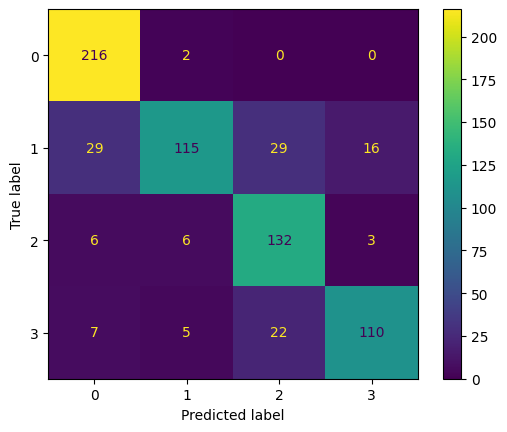

In [70]:
ConfusionMatrixDisplay.from_predictions(aug_y_test, np.argmax(aug_y_pred, axis=1))

In [73]:
model.save_weights('best_model.weights_bilstm3.weights.h5')

In [74]:
model3 = model.load_weights('/content/best_model.weights_bilstm3.weights.h5')

In [76]:
roc_auc_score(aug_y_test , aug_y_pred , multi_class='ovr', average='weighted')

np.float64(0.9591828476991612)

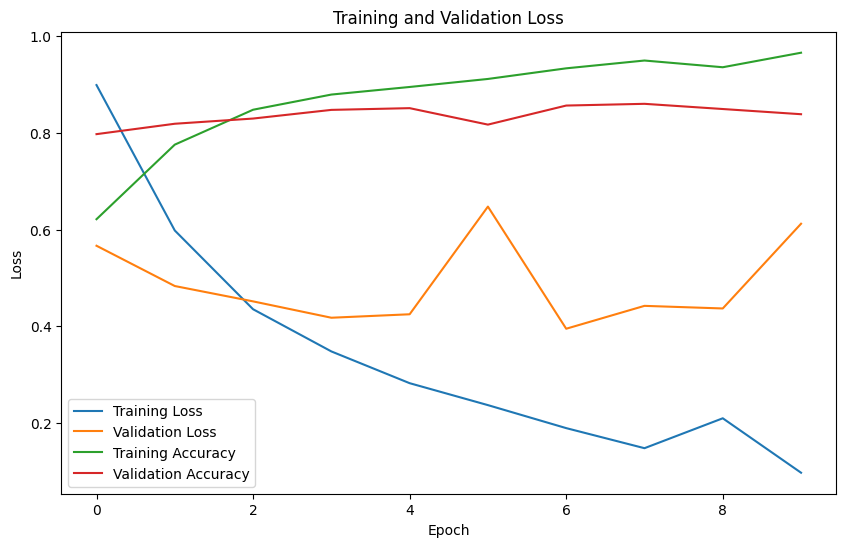

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


### Key Observations from Model Results

**1. Overall Performance Metrics:**
*   **Accuracy:** The model achieved an overall accuracy of **0.821** on the augmented test set (`aug_x_test`). This is a notable improvement compared to the previous model trained without data augmentation, which had an accuracy of 0.766.
*   **ROC-AUC Score:** The weighted average ROC-AUC score is **0.959**. This indicates that the model has excellent discriminatory power, meaning it can effectively distinguish between the different severity classes.

**2. Classification Report Analysis:**
*   **Class 0 (Not related or irrelevant):** This class exhibits outstanding performance with an F1-score of **0.91**, driven by a very high recall of **0.99** and a precision of **0.84**. The model is highly effective at identifying irrelevant tweets.
*   **Class 3 (High Severity):** Shows strong performance with an F1-score of **0.81** (precision 0.85, recall 0.76). This indicates good reliability in identifying critical information.
*   **Class 2 (Donation needs/offers or Caution/advice):** Has a good F1-score of **0.80**. While its recall is very high at **0.90** (meaning it captures most of these tweets), its precision is **0.72**. This suggests that while the model is good at finding instances of this class, it sometimes misclassifies other categories as Class 2 (false positives).
*   **Class 1 (Sympathy/Other Useful Information):** Has the lowest F1-score among the classes at **0.73**. Its precision is high (**0.90**), but its recall is relatively low at **0.61**. This implies that the model frequently misses actual Class 1 tweets, classifying them into other categories, even though its predictions *for* Class 1 are usually correct.

**3. Impact of Data Augmentation:**
*   Data augmentation has led to a significant overall performance boost across most metrics and classes, demonstrating its effectiveness in improving the model's generalization capabilities.


In summary, the augmented model represents a significant step forward in performance, with high overall metrics and strong identification of certain classes. The callbacks help ensure that the deployed model leverages the best generalization achieved during training, even if the training process itself reveals some level of overfitting.

## Optimizing using Grid Search CV
### Should be done later as will improve only 2-3%

In [ ]:
def opt_build_model(vocab_size, embed_dim, embedding_matrix, max_len=100 , num_classes = 5, lstm_units1=256, lstm_units2=128, dense_unit = 64 , dropout_rate1=0.5, dropout_rate2=0.5 , optimizer = 'Adam'):

    model = Sequential([
        Embedding(
            input_dim = vocab_size,
            output_dim = embed_dim,
            weights = [embedding_matrix],
            trainable = False,
            input_shape = (max_len,),
            name="embedding_layer"
        ),

        Bidirectional(LSTM(lstm_units1, return_sequences=True) , name = "bilstm1"),
        Dropout(dropout_rate1),
        Bidirectional(LSTM(lstm_units2 , return_sequences=False)),
        Dropout(dropout_rate2),
        Dense(dense_unit, activation="relu" , name="dense1"),
        Dense(num_classes, activation="softmax" , name="output")
    ])

    model.compile(optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [ ]:
from scikeras.wrappers import KerasClassifier

In [ ]:
model = KerasClassifier(model=opt_build_model, epochs = 15 ,verbose=1, vocab_size=4188, embed_dim=300, embedding_matrix=emb, max_len=100, num_classes=4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
dropout_rate1 = [0,0.1,0.2,0.4,0.5,0.8]
dropout_rate2 = [0,0.1,0.2,0.4,0.5,0.8]
lstm_units1 = [128,256,512,1024]
lstm_units2 = [64,128,256]
dense_unit = [16,32,64,128]
optm = ['SGD', 'RMSprop', 'Adagrad', 'Adadelta', 'Adam', 'Adamax', 'Nadam']

param = dict(model__dropout_rate1 = dropout_rate1 , model__dropout_rate2 = dropout_rate2,)

##model__lstm_units1 = lstm_units1 , model__lstm_units2 = lstm_units2 , model__dense_unit = dense_unit , model__optimizer = optm

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
grid = GridSearchCV(model, param, cv=3)
grid_result = grid.fit(new_x_train, new_y_train)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: 
All the 108 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
108 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 1501, in fit
    super().fit(X=X, y=y, sample_weight=sample_weight, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 770, in fit
    self._fit(
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py", line 925, in _fit
    X, y = self._initialize(X, y)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/scikeras/wrapper

In [ ]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))